Device: cuda


model.safetensors:   0%|          | 0.00/88.3M [00:00<?, ?B/s]

Epoch 1, Loss: 2823.38, Accuracy: 72.94%
Epoch 2, Loss: 2807.13, Accuracy: 72.94%
Epoch 3, Loss: 2804.93, Accuracy: 2.65%
Epoch 4, Loss: 2796.82, Accuracy: 72.19%
Epoch 5, Loss: 2799.98, Accuracy: 70.04%
Epoch 6, Loss: 2784.73, Accuracy: 50.53%
Epoch 7, Loss: 2778.61, Accuracy: 65.09%
Epoch 8, Loss: 2756.00, Accuracy: 39.71%
Epoch 9, Loss: 2738.74, Accuracy: 62.94%
Epoch 10, Loss: 2725.56, Accuracy: 45.69%


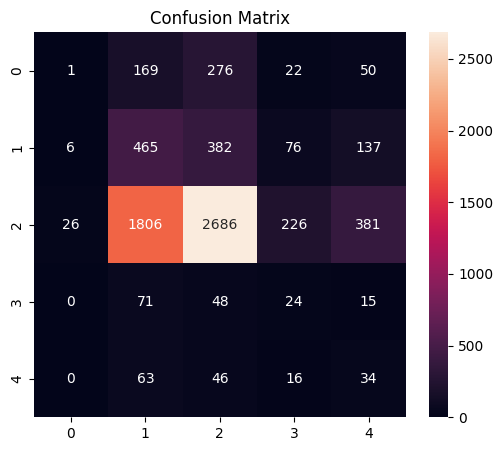


Classification Report:
              precision    recall  f1-score   support

           0       0.03      0.00      0.00       518
           1       0.18      0.44      0.26      1066
           2       0.78      0.52      0.63      5125
           3       0.07      0.15      0.09       158
           4       0.06      0.21      0.09       159

    accuracy                           0.46      7026
   macro avg       0.22      0.27      0.21      7026
weighted avg       0.60      0.46      0.50      7026



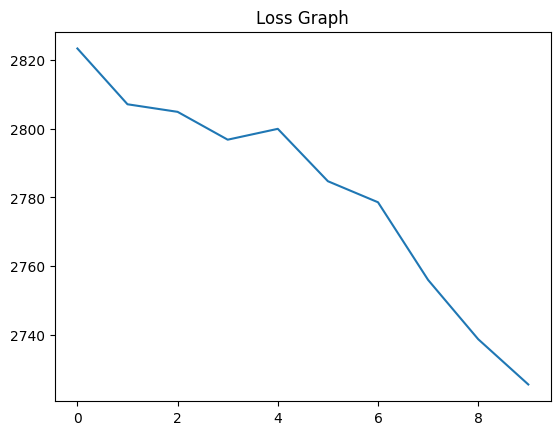

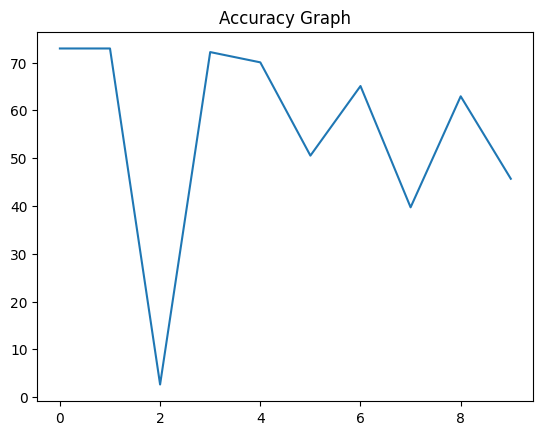

Model saved ✅


In [1]:
# =========================
# 1. Install
# =========================
!pip install timm -q

# =========================
# 2. Imports
# =========================
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# =========================
# 3. Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# 4. Dataset Path
# =========================
data_path = "/kaggle/input/datasets/sovitrath/diabetic-retinopathy-2015-data-colored-resized/colored_images/colored_images"

# =========================
# 5. Transform (with augmentation)
# =========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

# =========================
# 6. Load Dataset
# =========================
dataset = ImageFolder(data_path, transform=transform)

# Split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

# =========================
# 7  DeiT-III Model (FINAL)
# =========================
model = timm.create_model('deit3_small_patch16_224', pretrained=True)

# Change output layer
model.head = nn.Linear(model.head.in_features, 5)

model = model.to(device)

# =========================
# 8. CLASS WEIGHTS (IMPORTANT FIX)
# =========================
class_counts = [470, 1023, 5247, 126, 160]

weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
weights = weights / weights.sum()

criterion = nn.CrossEntropyLoss(weight=weights.to(device))

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# =========================
# 9. Training
# =========================
epochs = 10
loss_list = []
acc_list = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    loss_list.append(total_loss)

    # Validation
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    acc_list.append(accuracy)

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}, Accuracy: {accuracy:.2f}%")

# =========================
# 10. Confusion Matrix
# =========================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# =========================
# 11. Classification Report
# =========================
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, zero_division=0))

# =========================
# 12. Graphs
# =========================
plt.plot(loss_list)
plt.title("Loss Graph")
plt.show()

plt.plot(acc_list)
plt.title("Accuracy Graph")
plt.show()

# =========================
# 13. Save Model
# =========================
torch.save(model.state_dict(), "deit_model.pth")
print("Model saved ✅")

Device: cuda



Epoch 1
Train Loss: 1.5738
Val Loss: 1.4795
Accuracy: 70.01%
QWK: 0.0398

Epoch 2
Train Loss: 1.5500
Val Loss: 1.4650
Accuracy: 58.08%
QWK: 0.0487

Epoch 3
Train Loss: 1.4522
Val Loss: 1.4135
Accuracy: 69.33%
QWK: 0.0555

Epoch 4
Train Loss: 1.3898
Val Loss: 1.3714
Accuracy: 21.49%
QWK: 0.0382

Epoch 5
Train Loss: 1.3328
Val Loss: 1.2978
Accuracy: 30.93%
QWK: 0.0814

Epoch 6
Train Loss: 1.2313
Val Loss: 1.2969
Accuracy: 52.97%
QWK: 0.1134

Epoch 7
Train Loss: 1.1944
Val Loss: 1.2479
Accuracy: 56.68%
QWK: 0.1468

Epoch 8
Train Loss: 1.1689
Val Loss: 1.1947
Accuracy: 36.32%
QWK: 0.1092

Epoch 9
Train Loss: 1.1243
Val Loss: 1.2046
Accuracy: 52.39%
QWK: 0.1288

Epoch 10
Train Loss: 1.1031
Val Loss: 1.1775
Accuracy: 37.57%
QWK: 0.1204

Epoch 11
Train Loss: 1.0208
Val Loss: 1.1545
Accuracy: 46.41%
QWK: 0.1360

Epoch 12
Train Loss: 0.9810
Val Loss: 1.2167
Accuracy: 42.84%
QWK: 0.1138

Epoch 13
Train Loss: 0.9550
Val Loss: 1.1784
Accuracy: 39.41%
QWK: 0.1157

Epoch 14
Train Loss: 0.9121
Val L

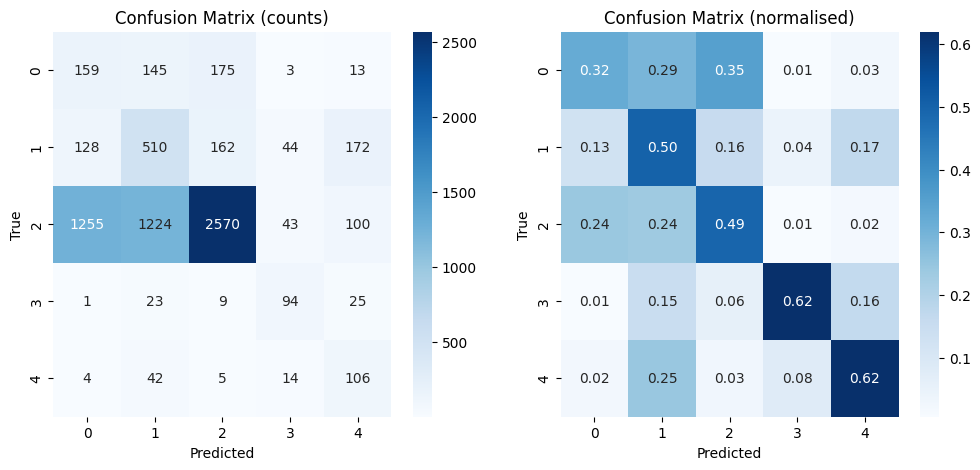


Classification Report:
              precision    recall  f1-score   support

           0       0.10      0.32      0.16       495
           1       0.26      0.50      0.34      1016
           2       0.88      0.49      0.63      5192
           3       0.47      0.62      0.54       152
           4       0.25      0.62      0.36       171

    accuracy                           0.49      7026
   macro avg       0.39      0.51      0.41      7026
weighted avg       0.71      0.49      0.55      7026



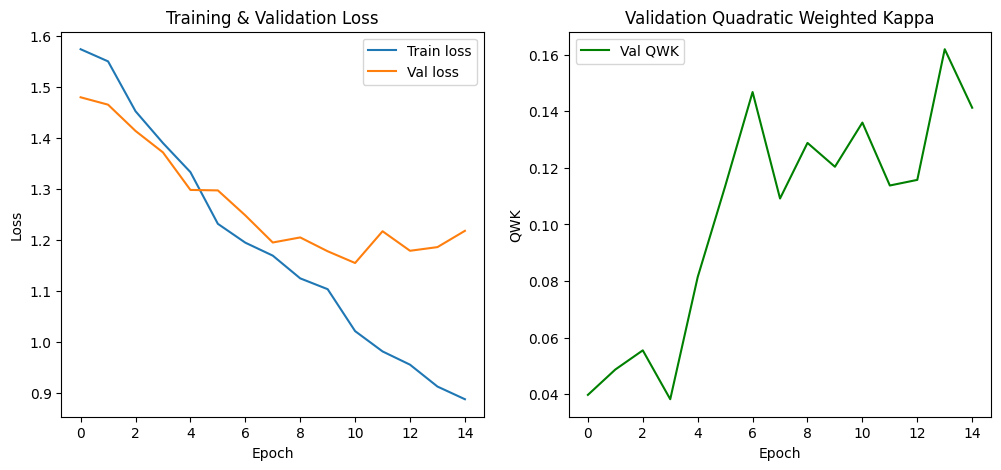

Model saved ✅


In [2]:
# =========================
# 1. Install
# =========================
!pip install timm -q

# =========================
# 2. Imports
# =========================
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import timm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

# =========================
# 3. Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# 4. Dataset Path
# =========================
data_path = "/kaggle/input/datasets/sovitrath/diabetic-retinopathy-2015-data-colored-resized/colored_images/colored_images"

# =========================
# 5. Transforms (IMPORTANT FIX)
# =========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # 🔥 REQUIRED for pretrained models
                         [0.229, 0.224, 0.225])
])

# =========================
# 6. Load Dataset
# =========================
dataset = ImageFolder(data_path, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

# =========================
# 7. Model (DeiT-III)
# =========================
model = timm.create_model('deit3_small_patch16_224', pretrained=True)
model.head = nn.Linear(model.head.in_features, 5)
model = model.to(device)

# =========================
# 8. Class Weights (IMPROVED)
# =========================
class_counts = [470, 1023, 5247, 126, 160]

weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
weights = weights / weights.mean()

criterion = nn.CrossEntropyLoss(weight=weights.to(device))

# =========================
# 9. Optimizer + Scheduler
# =========================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# =========================
# 10. Training
# =========================
epochs = 15

train_losses = []
val_losses = []
qwk_scores = []

for epoch in range(epochs):
    # ===== TRAIN =====
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # ===== METRICS =====
    acc = 100 * correct / total
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    qwk_scores.append(qwk)

    scheduler.step()

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Accuracy: {acc:.2f}%")
    print(f"QWK: {qwk:.4f}")

# =========================
# 11. Confusion Matrix
# =========================
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12,5))

# LEFT: COUNTS
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (counts)")
plt.xlabel("Predicted")
plt.ylabel("True")

# RIGHT: NORMALIZED
plt.subplot(1,2,2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues')
plt.title("Confusion Matrix (normalised)")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

# =========================
# 12. Classification Report
# =========================
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, zero_division=0))

# =========================
# 13. Graphs (LIKE YOUR IMAGE)
# =========================
plt.figure(figsize=(12,5))

# LOSS
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# QWK
plt.subplot(1,2,2)
plt.plot(qwk_scores, color="green", label="Val QWK")
plt.title("Validation Quadratic Weighted Kappa")
plt.xlabel("Epoch")
plt.ylabel("QWK")
plt.legend()

plt.show()

# =========================
# 14. Save Model
# =========================
torch.save(model.state_dict(), "deit_model.pth")
print("Model saved ✅")